##### --- 1. KÜTÜPHANELERİN İÇE AKTARILMASI ---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

##### --- 2. VERİ YÜKLEME VE İLK BAKIŞ ---

In [2]:
df = pd.read_csv("Salary_Data.csv")

In [3]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


##### --- 3. KEŞİFSEL VERİ ANALİZİ (EDA) VE GÖRSELLEŞTİRME ---
Ham verinin dağılımını görmek için bir saçılım grafiği (scatter plot) çiziyoruz.

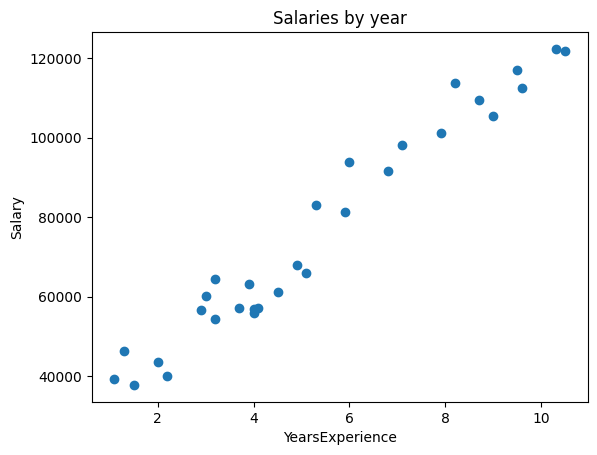

In [5]:
plt.scatter(x = df["YearsExperience"] , y = df["Salary"])
plt.title("Salaries by year")
plt.xlabel("YearsExperience") 
plt.ylabel("Salary")
plt.show()

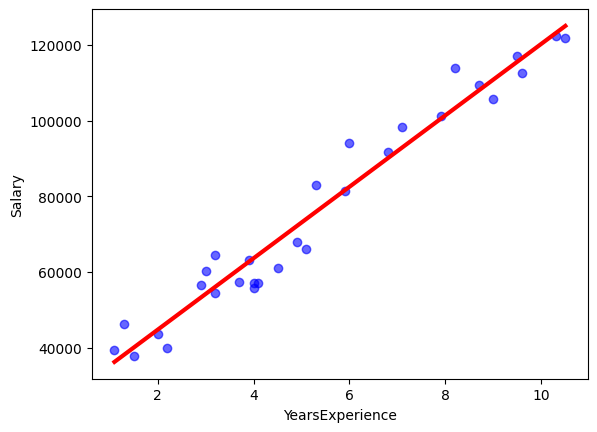

In [6]:
#Seaborn ile verinin üzerine oturan en iyi doğruyu (best fit line) çizdiriyoruz.
#Bu bize, yıllar arttıkça maaşın nasıl doğrusal bir eğilim gösterdiğini görsel olarak kanıtlıyor.

sns.regplot(
    data = df ,
    x = "YearsExperience" ,
    y = "Salary",
    scatter_kws = {"color": "blue", "alpha": 0.6},
    line_kws= {"color" : "red"  , "lw" : 3},
    ci= None 
)
plt.show()

##### --- 4. VERİ HAZIRLIĞI ---

In [7]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [8]:
# Veriyi %80 Eğitim (Train) ve %20 Test olarak ikiye bölüyoruz. 
# random_state=42 parametresi, kodu her çalıştırdığımızda aynı rastgele bölünmeyi elde etmemizi sağlar (tekrarlanabilirlik - reproducibility).

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [9]:
# Veriyi standartlaştırıyoruz (Ortalaması 0, Standart Sapması 1 olacak şekilde ölçekliyoruz).
scaler = StandardScaler()

In [10]:
# Eğitim verisine hem uyum sağlıyor (fit - ortalama ve varyansı öğreniyor) hem de dönüştürüyoruz (transform).
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
X_train_scaled

array([[ 1.77445774],
       [ 1.21912622],
       [-0.41216011],
       [-1.41869849],
       [-1.03690807],
       [-0.03036969],
       [-0.79395053],
       [-0.37745189],
       [-0.41216011],
       [ 0.94146047],
       [-1.34928205],
       [-1.27986561],
       [ 1.32325088],
       [-1.10632451],
       [ 0.66379471],
       [ 1.49679198],
       [ 0.24729607],
       [ 1.84387418],
       [ 0.55967005],
       [-0.68982587],
       [-0.44686833],
       [-0.23861901],
       [ 0.28200429],
       [-0.75924231]])

#### --- 5. MODELLEME ---

In [12]:
model = LinearRegression()

In [13]:
# Modeli eğitiyoruz. 'YearsExperience' (X) kullanarak 'Salary' (y) arasındaki matematiksel ilişkiyi ($y = mx + b$) öğreniyor.
model.fit(X_train_scaled , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### --- 6. TAHMİN VE DEĞERLENDİRME ---

In [14]:
y_pred = model.predict(X_test_scaled)

In [15]:
print("MAE Score : ", mean_absolute_error(y_test , y_pred ))
print("MSE Score : ", mean_squared_error(y_test , y_pred ))
print("R2 Score : ", r2_score(y_test , y_pred ))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE Score : ", rmse)

MAE Score :  6286.453830757746
MSE Score :  49830096.85590834
R2 Score :  0.9024461774180498
